# Imports + Results loading

In [257]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import json

json_path = "./data/evaluation_results_all_methods.json"

with open (json_path, 'r') as f:
    evaluation_results = json.load(f)

evaluation_results

{'waterfilling': {'embedding': {'1': 0.07514450867052024,
   '2': 0.10982658959537572,
   '3': 0.13872832369942195,
   '4': 0.1676300578034682,
   '5': 0.18497109826589594,
   '6': 0.21965317919075145,
   '7': 0.24277456647398843,
   '8': 0.2543352601156069,
   '9': 0.2658959537572254,
   '10': 0.27167630057803466,
   '11': 0.27167630057803466,
   '12': 0.2832369942196532,
   '13': 0.2832369942196532,
   '14': 0.2832369942196532,
   '15': 0.2947976878612717,
   '16': 0.30057803468208094,
   '17': 0.30057803468208094,
   '18': 0.30057803468208094,
   '19': 0.30057803468208094,
   '20': 0.30057803468208094},
  'graph': {'1': 0.0,
   '2': 0.005780346820809248,
   '3': 0.03468208092485549,
   '4': 0.046242774566473986,
   '5': 0.046242774566473986,
   '6': 0.05202312138728324,
   '7': 0.05202312138728324,
   '8': 0.05202312138728324,
   '9': 0.05202312138728324,
   '10': 0.05202312138728324,
   '11': 0.05202312138728324,
   '12': 0.05202312138728324,
   '13': 0.05202312138728324,
   '14': 

# Subplots

In [ ]:
# Goodgle Gemini was used to make this function 
def multi_bar_subplot(Data_original, accuracy_type, ylabel, max_y, subplot_variable = "dataset"):
    """
    Generates a figure with multiple grouped bar charts (subplots) based on either
    'dataset' or 'method', where each category has a distinct color,
    and bars within the category fade to white as the index 'j' increases.

    Args:
        Data_original (dict): Outer keys are subplot categories (e.g., dataset names). 
                              Inner values are dictionaries: {Category_name: [acc_1, acc_2, ...]}
        accuracy_type (list): List of integers (e.g., [1, 5, 10]) corresponding to the values.
        title (str): Main title for the entire figure.
        xlabel (str): X-axis label for the bottom subplot.
        ylabel (str): Y-axis label for all subplots.
        max_y (float): Maximum Y-axis limit (e.g., 1.0).
        subplot_variable (str): Controls how subplots are arranged ('dataset' or 'method').
    """
    
    # Imports are assumed: import matplotlib.pyplot as plt, import numpy as np, 
    # import matplotlib.colors as mcolors
    
    # Get a qualitative colormap (one distinct color per category)
    cmap = plt.get_cmap('tab10')
    dataset_list = list(Data_original.keys())
    
    # ------------------------------------------------------------------
    # --- Check for subplot_variable and set up figure/axes structure ---
    # ------------------------------------------------------------------
    
    if subplot_variable == "dataset": 
        n_subplots = len(dataset_list)
        # Use a large figure size for vertical arrangement
        fig, AX = plt.subplots(nrows=n_subplots, ncols=1, figsize=(12, 5 * n_subplots))
        
        # Ensure AX is an iterable array even if n_subplots=1
        if n_subplots == 1:
            AX = np.array([AX]) 
        
        # Outer loop iterates through each dataset for a subplot
        for dataset in range(n_subplots):
            current_ax = AX[dataset]
            data_key = dataset_list[dataset]
            Data = Data_original[data_key]
            
            # Use dataset name as subplot title
            current_ax.set_title(data_key, fontsize=25, fontweight='bold', loc='left')

            # --- Start Plotting Logic ---
            categories = list(Data.keys())
            n_cat = len(categories)
            n_acc = len(accuracy_type)
        
            # Basic layout parameters
            x_indices = np.arange(n_cat)
            total_width = 0.8
            bar_width = total_width / n_acc

            # Loop through Categories (Outer Loop)
            for i, cat in enumerate(categories):
                values = Data[cat]
                # Fix for the previous bug: iterate over list indices, not list values
                values =  [values[i] for i in values]
                
                # Get base color for this category
                base_color = cmap(i % 10) 
                base_rgb = mcolors.to_rgb(base_color)
                
                # 3. Loop through Accuracy Levels (Inner Loop - The Bars)
                k = 0 # Start counter k from 0
                for j, val in enumerate(values):
                    if j+1 in accuracy_type :
                        # Calculate position to center the group on the tick
                        offset = (k - n_acc / 2 + 0.5) * bar_width
                        pos = x_indices[i] + offset
                        
                        # --- Gradient Logic ---
                        # Calculate "whiteness" factor based on index k.
                        # k=0 -> Factor 0 (Pure Color)
                        # k=max -> Factor approaches 0.8 (Very light, but not invisible)
                        white_factor = ((max(n_acc, 1)-k) / max(n_acc - 1, 1)) * 0.7
                        
                        # Mix base color with white
                        # New_Color = Base * (1 - factor) + White * factor
                        mixed_color = [c * (1 - white_factor) + 1.0 * white_factor for c in base_rgb]
                        
                        # Plot the bar
                        AX[dataset].bar(pos, val, width=bar_width, color=mixed_color, edgecolor='white', linewidth=0.7)
                        k+=1
                        
            # 4. Styling and Labels (Specific to the current subplot)
            # Reduced font size for better fit in subplots
            current_ax.set_ylabel(ylabel, fontsize=18, fontweight='bold')
            
            # Configure X-axis ticks
            current_ax.set_xticks(x_indices)
            current_ax.set_xticklabels(categories, fontsize=18, fontweight='bold')
            
            # Y-axis limit and grid
            current_ax.set_ylim(0, ymax=max_y)
            current_ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

            # Add real values on top of the bars
            for rect in current_ax.patches:
                height = rect.get_height()
                x_pos = rect.get_x() + rect.get_width() / 2
                
                if height >= 0:
                    current_ax.text(
                        x_pos, 
                        height + (max_y * 0.005), # Smaller dynamic offset
                        f'{height:.2f}', # Rounded to 2 decimal places for brevity
                        ha='center', 
                        va='bottom',
                        fontsize=12, # Significantly reduced font size for bar labels
                        fontweight = 'bold',
                        rotation=0 # Rotate for better fit in tight space
                    )

            # 5. Create a Neutral Legend (Only on the first subplot)
            if dataset == 0:
                legend_patches = []
                # Recalculate n_acc based on the actual values used
                n_acc_used = len(accuracy_type)
                for j, acc_k in enumerate(accuracy_type):
                    # Create a matching gray gradient for the legend
                    gray_val = 1.0 - (j / max(n_acc_used - 1, 1)) * 0.7 # Darker for lower k
                    color_patch = (gray_val, gray_val, gray_val)
                    
                    patch = plt.Rectangle((0,0), 1, 1, color=color_patch, label=f'Top-{acc_k}')
                    legend_patches.append(patch)
                    
                # Reduced legend font size significantly for subplots
                current_ax.legend(handles=legend_patches, loc='upper right', fontsize=18)

        
        
        # Adjust layout for multiple plots
        plt.tight_layout(rect=[0, 0, 1, 0.96])


    # ------------------------------------------------------------------
    # --- Logic for subplot_variable == "method" (Similar logic) ---
    # ------------------------------------------------------------------
    
    elif subplot_variable == "method":
        
        # Assuming the structure is consistent and 'waterfilling' key exists
        method_list = list(Data_original[dataset_list[0]].keys())
        n_subplots = len(method_list)

        # Use a large figure size for vertical arrangement
        fig, AX = plt.subplots(nrows=n_subplots, ncols=1, figsize=(12, 5 * n_subplots))
        
        if n_subplots == 1:
            AX = np.array([AX]) 
        
        for method in range(n_subplots):
            current_ax = AX[method]
            method_key = method_list[method]
            
            # Reconstruct Data dictionary: keys are dataset names, values are the method's results
            Data = {dataset: Data_original[dataset][method_key] for dataset in dataset_list}

            # Use method name as subplot title
            current_ax.set_title(method_key, fontsize=25, fontweight='bold', loc='left')
            
            # --- Start Plotting Logic (Same as above, categories are now datasets) ---
            categories = list(Data.keys())
            n_cat = len(categories)
            n_acc = len(accuracy_type)
        
            # Basic layout parameters
            x_indices = np.arange(n_cat)
            total_width = 0.8
            bar_width = total_width / n_acc

            # Loop through Categories (Outer Loop)
            for i, cat in enumerate(categories):
                values = Data[cat]
                # Fix for the previous bug: iterate over list indices, not list values
                values =  [values[i] for i in values]
                
                base_color = cmap(i % 10) 
                base_rgb = mcolors.to_rgb(base_color)

                # 3. Loop through Accuracy Levels (Inner Loop - The Bars)
                k = 0 # Start counter k from 0
                for j, val in enumerate(values):
                    if j+1 in accuracy_type :
                        # Calculate position to center the group on the tick
                        offset = (k - n_acc / 2 + 0.5) * bar_width
                        pos = x_indices[i] + offset
                        
                        # --- Gradient Logic ---
                        # Calculate "whiteness" factor based on index k.
                        # k=0 -> Factor 0 (Pure Color)
                        # k=max -> Factor approaches 0.8 (Very light, but not invisible)
                        white_factor = ((max(n_acc, 1)-k) / max(n_acc - 1, 1)) * 0.7
                        
                        # Mix base color with white
                        # New_Color = Base * (1 - factor) + White * factor
                        mixed_color = [c * (1 - white_factor) + 1.0 * white_factor for c in base_rgb]
                        
                        # Plot the bar
                        AX[method].bar(pos, val, width=bar_width, color=mixed_color, edgecolor='white', linewidth=0.7)
                        k+=1

            # 4. Styling and Labels (Specific to the current subplot)
            current_ax.set_ylabel(ylabel, fontsize=18, fontweight='bold')
            
            # Configure X-axis ticks
            current_ax.set_xticks(x_indices)
            current_ax.set_xticklabels(categories, fontsize=18, fontweight='bold')
            
            # Y-axis limit and grid
            current_ax.set_ylim(0, ymax=max_y)
            current_ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

            # Add real values on top of the bars
            for rect in current_ax.patches:
                height = rect.get_height()
                x_pos = rect.get_x() + rect.get_width() / 2
                
                if height >= 0:
                    current_ax.text(
                        x_pos, 
                        height + (max_y * 0.005), 
                        f'{height:.2f}', 
                        ha='center', 
                        va='bottom',
                        fontsize=12,
                        fontweight = 'bold',
                        rotation=0
                    )

            # 5. Create a Neutral Legend (Only on the first subplot)
            if method == 0:
                legend_patches = []
                n_acc_used = len(accuracy_type)
                for j, acc_k in enumerate(accuracy_type):
                    gray_val = 1.0 - (j / max(n_acc_used - 1, 1)) * 0.7
                    color_patch = (gray_val, gray_val, gray_val)
                    patch = plt.Rectangle((0,0), 1, 1, color=color_patch, label=f'Top-{acc_k}')
                    legend_patches.append(patch)
                    
                current_ax.legend(handles=legend_patches, loc='upper right', fontsize=18)

        
        
        # Adjust layout for multiple plots
        plt.tight_layout(rect=[0, 0, 1, 0.96])

    # ------------------------------------------------------------------
    # --- Error handling ---
    # ------------------------------------------------------------------
    else :
        raise ValueError("Invalid value for subplot_variable. Must be 'dataset' or 'method'.")
    
    # Show the plot at the end
    plt.show()



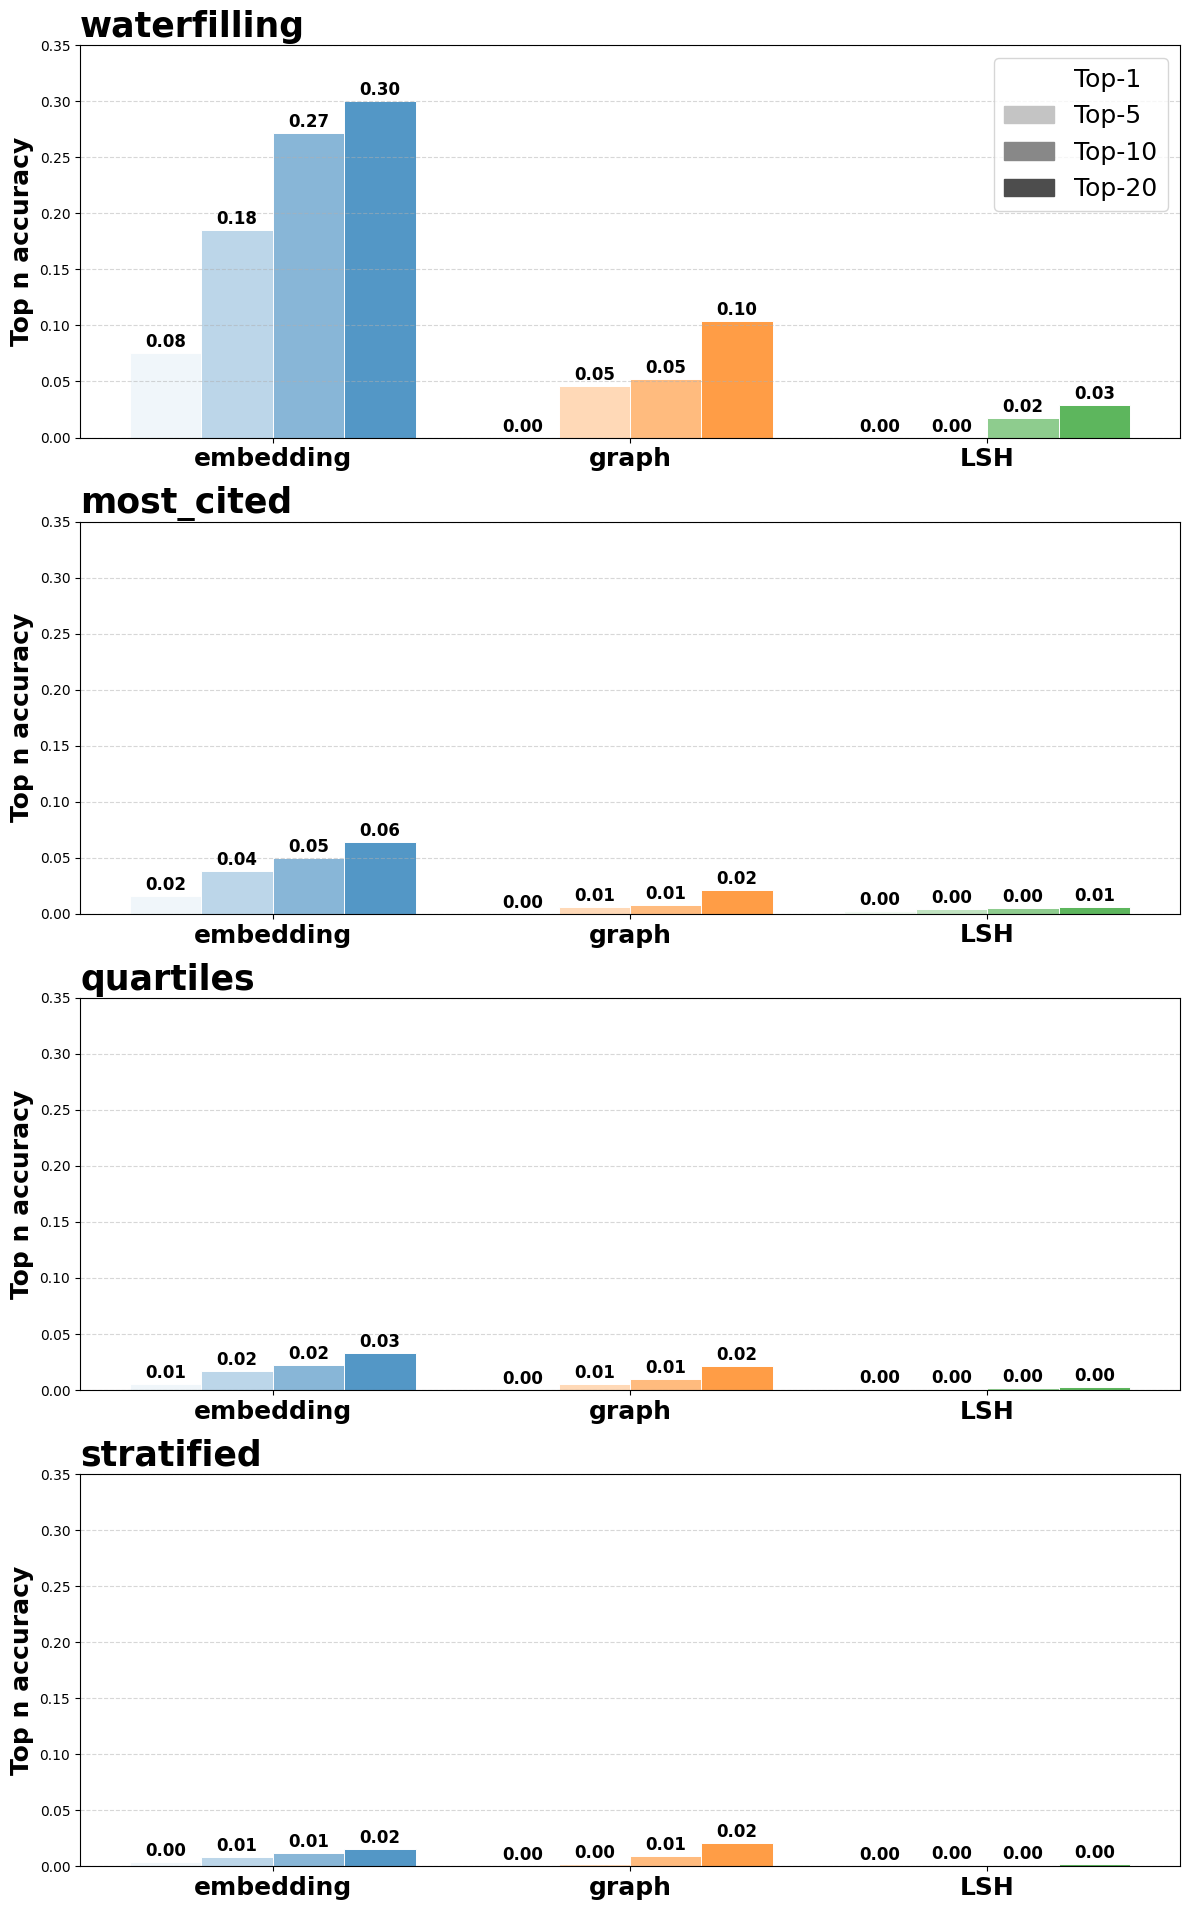

In [255]:
multi_bar_subplot(Data_original=evaluation_results,
                   accuracy_type=[1,5,10,20],
                   ylabel = "Top n accuracy",
                   max_y = 0.35,
                   subplot_variable="dataset")

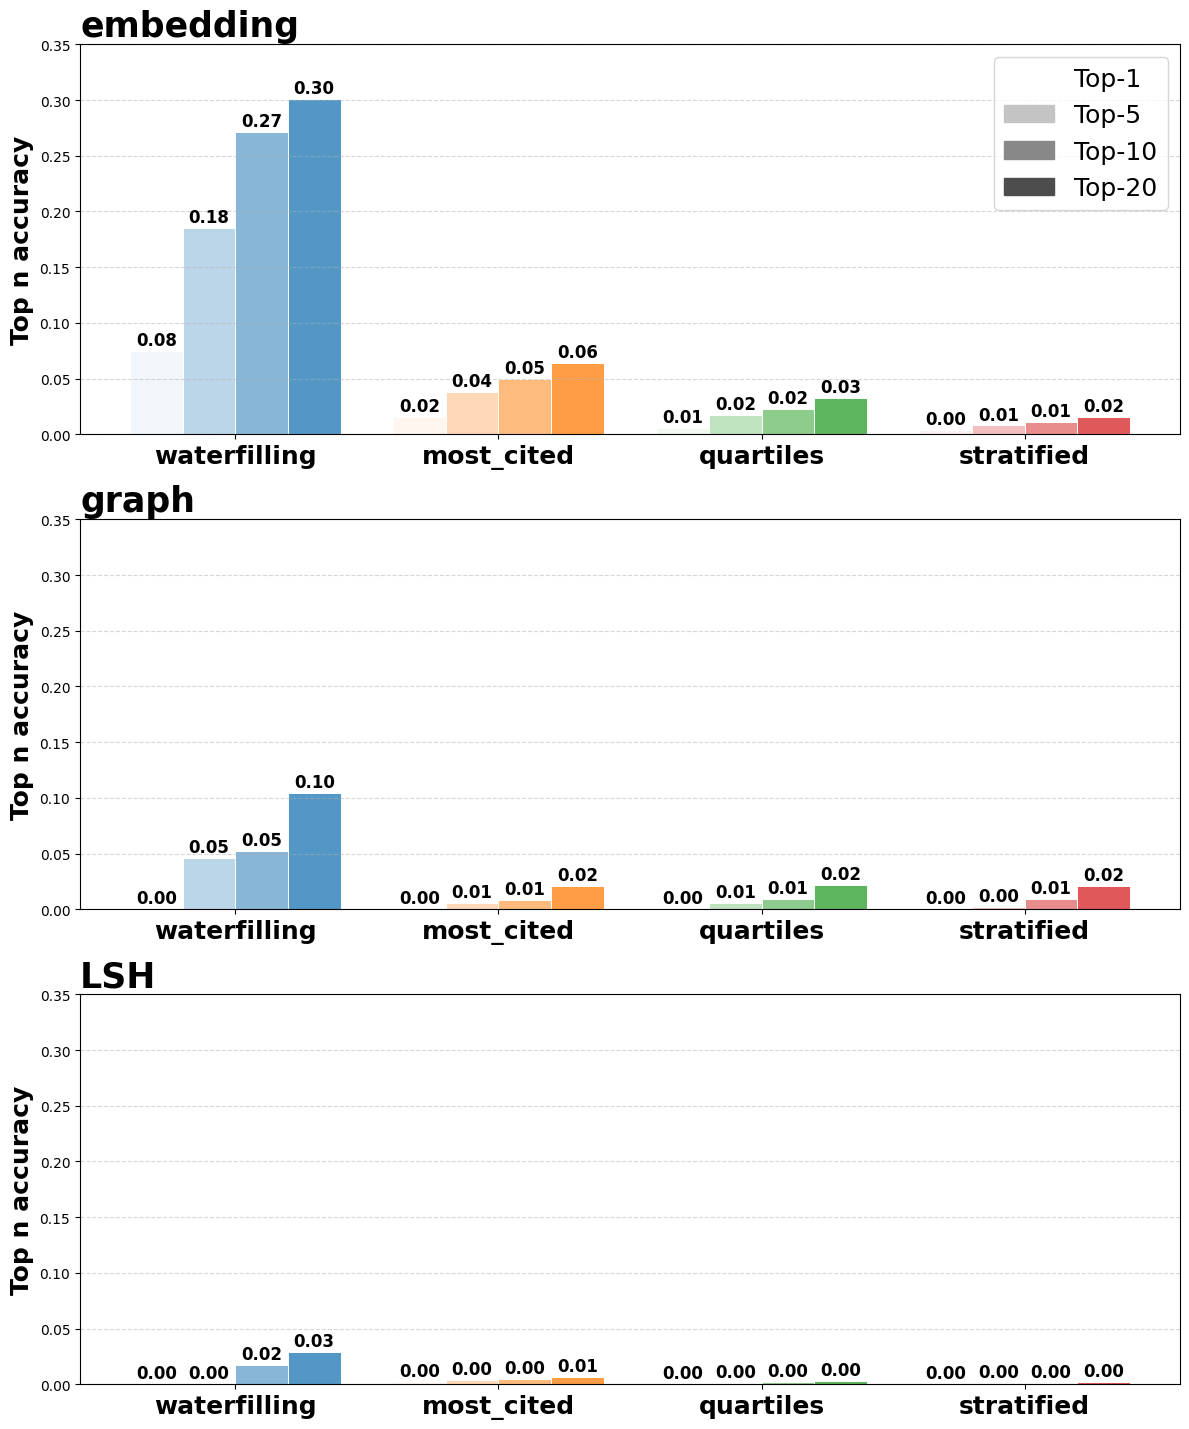

In [252]:
multi_bar_subplot(Data_original=evaluation_results,
                   accuracy_type=[1,5,10,20],
                   ylabel = "Top n accuracy",
                   max_y = 0.35,
                   subplot_variable="method")